In [2]:
# Modulos para ler os arquivos .txt
import os
import glob
import shutil

# Pacote para o DataFrame e Plots
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Pacotes de NLP
import nltk
import re
import spacy
from sklearn.feature_extraction.text import CountVectorizer



In [3]:
# Carregando recursos
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
stop_words_pt = nltk.corpus.stopwords.words('portuguese')

try:
    nlp = spacy.load("pt_core_news_sm")
    print("Modelo de linguagem do spaCy carregado com sucesso!")
except:
    print("Modelo pt_core_news_sm não encontrado. Executando python -m spacy download pt_core_news_sm")   
    nlp = None

Modelo de linguagem do spaCy carregado com sucesso!


In [4]:
# Definição das pastas de entreda e saída
PASTA_ENTRADA = "entrada_processos"
PASTA_SAIDA = "PII_anonimizados"

# Limpar e recriar a pasata de saída
if os.path.exists(PASTA_SAIDA): shutil.rmtree(PASTA_SAIDA)
os.makedirs(PASTA_SAIDA)

### Exploração de Dados

In [5]:
# Carregar todo o corpusde texto em memória

corpus_total = []
nomes_arquivos = []

arquivo_analise = glob.glob(os.path.join(PASTA_ENTRADA, "*.txt"))

for caminho in arquivo_analise:
    with open(caminho, 'r', encoding='utf-8') as f:
        corpus_total.append(f.read())
        nomes_arquivos.append(os.path.basename(caminho))

print (f"Total de arquivos carregados: {len(corpus_total)}")



Total de arquivos carregados: 10


In [6]:
nomes_arquivos

['processo_001.txt',
 'processo_002.txt',
 'processo_003.txt',
 'processo_004.txt',
 'processo_005.txt',
 'processo_006.txt',
 'processo_007.txt',
 'processo_008.txt',
 'processo_009.txt',
 'processo_010.txt']

In [7]:
# Vetorização Inicial
vec_analise = CountVectorizer(stop_words=stop_words_pt, min_df=0.01)
X_analise = vec_analise.fit_transform(corpus_total)

print (f"Shape da matriz de frequencias: {X_analise.shape}")

Shape da matriz de frequencias: (10, 427)


In [8]:
# Soma Frenquencias Globais
soma_palavras = X_analise.sum(axis=0)

palavras_freq = [(word, soma_palavras[0, idx]) for word, idx in vec_analise.vocabulary_.items()]

In [9]:
# Criar DataFrane

df_freq_global = pd.DataFrame(palavras_freq, columns=['Termo', 'Frequencia'])
df_freq_global = df_freq_global.sort_values(by='Frequencia', ascending=False)

In [10]:
# Mostrar Tabela de Frenquencia
df_freq_global.head(20)

,Termo,Frequencia
86,00,27
13,nº,22
4,direito,21
16,2023,21
89,requer,20
19,autor,20
44,ação,20
36,email,20
147,ré,13
59,código,13


C:\Users\ricardo.ribeiro\AppData\Local\Temp\ipykernel_3008\745195723.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_freq_global.head(20), x='Frequencia', y='Termo', palette='viridis')


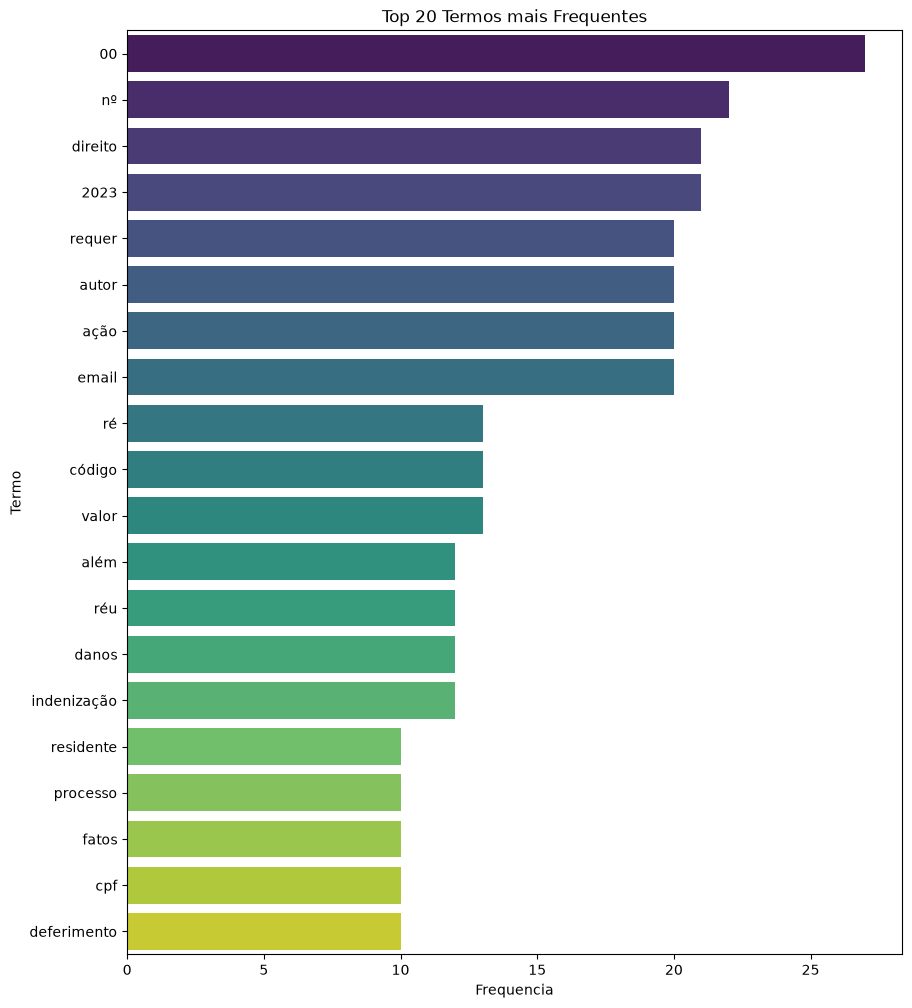

In [11]:
#Mostrar um plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 12))
sns.barplot(data=df_freq_global.head(20), x='Frequencia', y='Termo', palette='viridis')
plt.title('Top 20 Termos mais Frequentes')
plt.show()

In [12]:
# Criar lista de stopwords jurídicas com as palavras acima de 20 ocorrências, ignorando números

stopwords_juridicas = []
TOP_N = 20

for palavra, freq in palavras_freq:
    if not palavra.isdigit():
        stopwords_juridicas.append(palavra)
    if len(stopwords_juridicas) >= TOP_N:
        break

In [13]:
# Cria uma lista consolidando stop words

stop_words_juridico = stop_words_pt + stopwords_juridicas

In [14]:
len(stop_words_juridico)

227

### Criação das Tarefas

In [15]:
# Extriair entidade usando Regex
def extrair_entidade(texto):
    dados = {
        'CPFs': [],
        'Emails': [],
        'Datas': [],
        'Valores (R$)': [],
        'Legislação': []
    }

# Extrair CPFs
    dados['CPFs'] = re.findall(r'\b\d{3}\.\d{3}\.\d{3}-\d{2}\b', texto)

# Extraie Emails
    dados['Emails'] = re.findall(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', texto)

# Extraie Datas
    datas_simples = re.findall(r'\d{2}/\d{2}/\d{4}', texto)
    dados['Datas'].extend(datas_simples)

# Extraie Valores Monetários
    dados['Valores'] = re.findall(r'(?<=R\\$\\s)[\\d.,]+', texto)

# Extrair Legislação,
    dados['Legislação'] = re.findall(r'Lei nº? \\d+(?:\\.\\d+)?', texto, flags=re.IGNORECASE)

    return dados
    

In [16]:
# Identificar tema do processo,

from ast import pattern

from soupsieve import match


def identificar_tema(texto):
    pattern = r'(?<=DOS FATOS)([\\s\\S]*?)(?=O valor|R\\$|DOS PEDIDOS)'
    match = re.search(pattern, texto, flags=re.IGNORECASE)
    if not match:
        return "Seção DOS FATOS não foi encontrada"
        
    texto_fatos = match.group(0).strip()

    # Limpeza básica
    texto_limpo = re.sub(r'[^\\w\\s]', '', texto_fatos.lower())
    texto_limpo = re.sub(r'\\d+', '', texto_limpo)
    texto_limpo = re.sub(r'\\s+', ' ', texto_limpo).strip()
    
    vectorizer = CountVectorizer(
        stop_words=stop_words_juridico,
        ngram_range=(1, 2),
        max_features=15
    )
   
    try:
        X = vectorizer.fit_transform([texto_limpo])
        vocab = vectorizer.get_feature_names_out()
        contagens = X.toarray().sum(axis=0)

        df_freq = pd.DataFrame({'termo': vocab, 'freq': contagens}).sort_values(by='freq', ascending=False)
    
        return ",".join(df_freq['termo'].head(3).tolist())
    except Exception:
        return "Conteúdo insuficiente para análise\"\n"

In [17]:
# Anomimizar Texto,
def anomimizar_texto(texto):
    
    # Regex para CPF e E-Mails,
    txt = re.sub(r'\d{3}\.\d{3}\.\d{3}-\d{2}', '[CPF]', texto)
    txt = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', '[EMAIL]', txt)
    
    # NER (Named Entity Recognition) - Spacy,
    if nlp:
        doc = nlp(txt)
        for ent in reversed(doc.ents):
            if ent.label_ == 'PER':
                txt = txt[:ent.start_char] + '[PESSOA]' + txt[ent.end_char:]
            if ent.label_ == 'ORG':
                txt = txt[:ent.start_char] + '[EMPRESA]' + txt[ent.end_char:]
    
    return txt

### Loop principal para Pipeline NLP

In [19]:
# Lista para o DataFrame
relatorio_geral = []
    
    # Loop
lista_arquivos = glob.glob(os.path.join(PASTA_ENTRADA, '*.txt'))
    
for caminho in lista_arquivos:
    nome_arquivo = os.path.basename(caminho)
    
    # Leitura
    with open(caminho, 'r', encoding='UTF-8') as f:
            texto_bruto = f.read()
    
    print(f"[OK] Processando: {nome_arquivo} -> Salvo em {PASTA_SAIDA}")
    
    # Extração de Entidades
    dados_extraidos = extrair_entidade(texto_bruto)
    
    # Identificar Tema
    tema_identificado = identificar_tema(texto_bruto)
    
    # Anomimizar Texto
    texto_anonimizado = anomimizar_texto(texto_bruto)
    
    # Salvar Arquivo
    caminho_saida = os.path.join(PASTA_SAIDA, f"safe_{nome_arquivo}")
    
    with open(caminho_saida, 'w', encoding='UTF-8') as f:
            f.write(texto_anonimizado)
    
    registro = {
        'Nome do Arquivo': nome_arquivo,
        'Tema': tema_identificado,
        'CPFs': ', '.join(dados_extraidos['CPFs']),
        'Emails': ', '.join(dados_extraidos['Emails']),
        'Datas': ', '.join(dados_extraidos['Datas']),
        'Valores': ', '.join(dados_extraidos['Valores']),
        'Legislações': ', '.join(dados_extraidos['Legislação']),
        'Arquivo Saída': caminho_saida
    }
    
    relatorio_geral.append(registro)
    print(f"[OK] Arquivo: {nome_arquivo} processado, Arquivo Anonimizado: {caminho_saida}")
    
    print("\nProcessamento Concluído")

[OK] Processando: processo_001.txt -> Salvo em PII_anonimizados
[OK] Arquivo: processo_001.txt processado, Arquivo Anonimizado: PII_anonimizados\safe_processo_001.txt

Processamento Concluído
[OK] Processando: processo_002.txt -> Salvo em PII_anonimizados
[OK] Arquivo: processo_002.txt processado, Arquivo Anonimizado: PII_anonimizados\safe_processo_002.txt

Processamento Concluído
[OK] Processando: processo_003.txt -> Salvo em PII_anonimizados
[OK] Arquivo: processo_003.txt processado, Arquivo Anonimizado: PII_anonimizados\safe_processo_003.txt

Processamento Concluído
[OK] Processando: processo_004.txt -> Salvo em PII_anonimizados
[OK] Arquivo: processo_004.txt processado, Arquivo Anonimizado: PII_anonimizados\safe_processo_004.txt

Processamento Concluído
[OK] Processando: processo_005.txt -> Salvo em PII_anonimizados
[OK] Arquivo: processo_005.txt processado, Arquivo Anonimizado: PII_anonimizados\safe_processo_005.txt

Processamento Concluído
[OK] Processando: processo_006.txt -> Sa

In [20]:
# Criar o DataFrame do Relatório Geral
df_relatorio = pd.DataFrame(relatorio_geral)

df_relatorio

,Nome do Arquivo,Tema,CPFs,Emails,Datas,Valores,Legislações,Arquivo Saída
0,processo_001.txt,Seção DOS FATOS não foi encontrada,234.567.890-11,maria.santos@email.com,22/04/2023,,,PII_anonimizados\safe_processo_001.txt
1,processo_002.txt,Seção DOS FATOS não foi encontrada,345.678.901-22,carlos.ferreira@email.com,10/05/2023,,,PII_anonimizados\safe_processo_002.txt
2,processo_003.txt,Seção DOS FATOS não foi encontrada,456.789.012-33,ana.rodrigues@email.com,18/06/2023,,,PII_anonimizados\safe_processo_003.txt
3,processo_004.txt,Seção DOS FATOS não foi encontrada,567.890.123-44,ricardo.costa@email.com,30/07/2023,,,PII_anonimizados\safe_processo_004.txt
4,processo_005.txt,Seção DOS FATOS não foi encontrada,678.901.234-55,fernanda.souza@email.com,05/08/2023,,,PII_anonimizados\safe_processo_005.txt
5,processo_006.txt,Seção DOS FATOS não foi encontrada,789.012.345-66,pedro.martins@email.com,14/09/2023,,,PII_anonimizados\safe_processo_006.txt
6,processo_007.txt,Seção DOS FATOS não foi encontrada,890.123.456-77,juliana.araujo@email.com,25/10/2023,,,PII_anonimizados\safe_processo_007.txt
7,processo_008.txt,Seção DOS FATOS não foi encontrada,901.234.567-88,marcos.teixeira@email.com,12/11/2023,,,PII_anonimizados\safe_processo_008.txt
8,processo_009.txt,Seção DOS FATOS não foi encontrada,012.345.678-99,beatriz.cardoso@email.com,08/12/2023,,,PII_anonimizados\safe_processo_009.txt
9,processo_010.txt,Seção DOS FATOS não foi encontrada,112.233.445-00,rafael.pereira@email.com,20/01/2024,,,PII_anonimizados\safe_processo_010.txt
